In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

In [5]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

X_train.head(2)
X_test.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,29.498846,1,1,15.2458,C
1,second,male,31.000000,0,0,10.5000,S


## Scaling ##
### Scaling is the process of transforming features to a similar scale so o they're on a comparable numeric range. . ###

#### Foe example Distance-Based Algorithms Break Without Scaling Algorithms like KNN, SVM, and K-Means compute distances between points. If one feature ranges from 0–10,000 and another from 0–1, the large-range feature will almost entirely control the distance calculation, effectively ignoring the other features. ####



### Standard Scaling (Z-score Normalization) ###
#### it transforms the data to have a mean of 0 and a standard deviation of 1 and  formula is z = (x − μ) / σ   ####

#### here x is the value, μ is the mean, and σ is the standard deviation. ####
 ####

<Axes: xlabel='Age', ylabel='Density'>

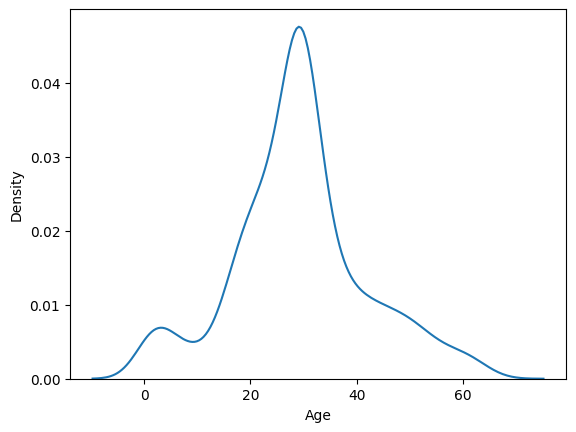

In [6]:
sns.kdeplot(data=X_train , x = X_train['Age'])

In [7]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()

ss.fit(X_train[['Age']]) # compute Z score 

X_train['Age']=ss.transform(X_train[['Age']]).ravel()
X_test['Age']=ss.transform(X_test[['Age']]).ravel()

X_train.sample(4)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
316,first,male,0.864546,0,0,0.00,S
104,third,male,1.584462,0,0,0.00,S
111,third,male,-0.815257,0,0,7.65,S
0,first,male,1.304495,0,0,28.50,S


In [8]:

X_train['Age'].mean() # around 0 

np.float64(3.165784466257872e-16)

Text(0.5, 1.0, 'Plot of Age after Standard Scaling , plot as previous only scale has chanegd  ')

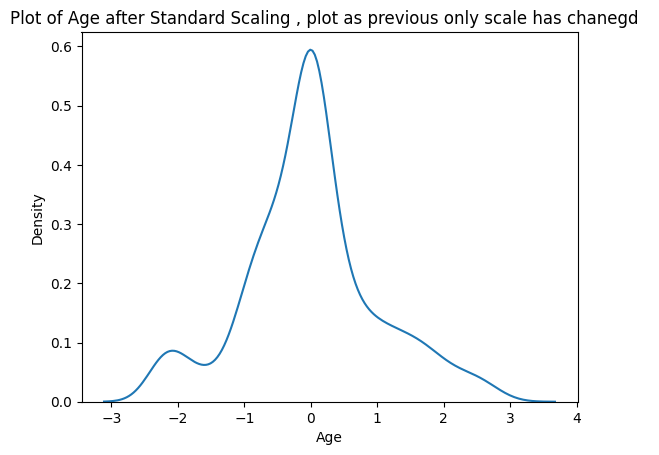

In [9]:
sns.kdeplot(data=X_train , x = X_train['Age'])
plt.title('Plot of Age after Standard Scaling , plot as previous only scale has chanegd  ' )

# Scale remained same , see two kdeplot before and after standard scaling , 
# they are same 

## MinMAx Scaling (Normalization) ##
#### it transforms the data to a fixed range, usually 0 to 1. The formula is:  

#### X_scaled = (X - X_min) / (X_max - X_min) ####

#### It works on non normal distribution like  skewed distribution ####

<Axes: xlabel='Fare', ylabel='Density'>

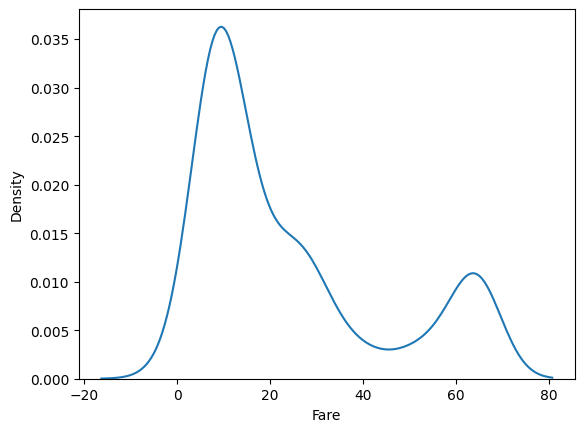

In [10]:
sns.kdeplot(data=X_train , x = X_train['Fare'])  # Fare clipped earlier 


In [11]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

mms.fit(X_train[['Fare']])


X_train['Fare'] = mms.transform(X_train[['Fare']]).ravel()
X_test['Fare'] = mms.transform(X_test[['Fare']]).ravel()

In [12]:
X_train["Fare"].describe() # min 0 , max 1 , mean close to zero 

count    707.000000
mean       0.368633
std        0.313162
min        0.000000
25%        0.123131
50%        0.224575
75%        0.473878
max        1.000000
Name: Fare, dtype: float64

Text(0.5, 1.0, 'Plot of Fare after MaxMin Scaling , plot same only scale has  changed  ')

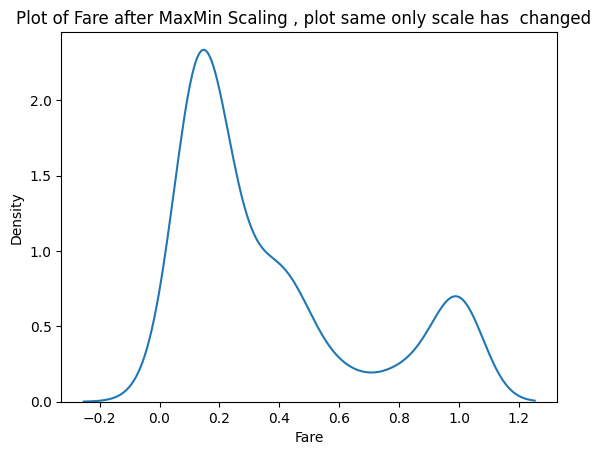

In [13]:
sns.kdeplot(data=X_train , x = X_train['Fare'])  
plt.title('Plot of Fare after MaxMin Scaling , plot same only scale has  changed  ' )


## Robust Scaling ##
#### it is a scaling technique that uses the median and the interquartile range (IQR) to scale the data. It is robust to outliers, meaning that it is not affected by extreme values in the data. The formula for robust scaling is:

#### Formula is : X_scaled = (X - X_median) / IQR

### When to use it -> for  data with so many outliners ###

#### The Problem with Standard Scaling (Z-score) / Standard scaling is that it uses mean and std , both are highly influenced by outliners . 

#### Robust uses median and IQR 

In [14]:
mark = pd.read_csv('marks_dataset.csv')
mark.head(4)

FileNotFoundError: [Errno 2] No such file or directory: 'marks_dataset.csv'

Text(0.5, 1.0, 'Plot of maths_marks before Robust Scaling')

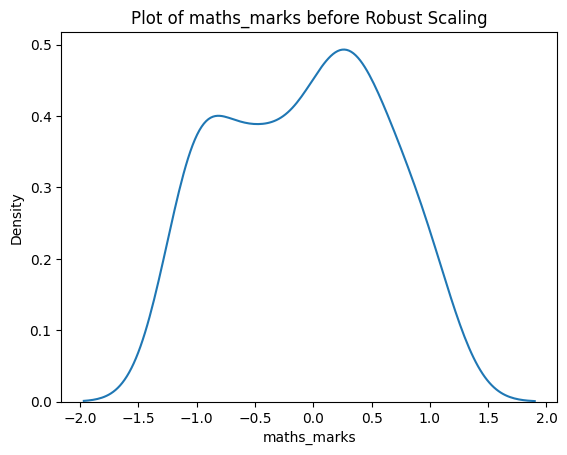

In [ ]:
sns.kdeplot(data=mark , x = mark['maths_marks'])
plt.title('Plot of maths_marks before Robust Scaling' )

In [ ]:
mark['maths_marks'].describe()

count    100.000000
mean      48.950000
std       28.999956
min        2.000000
25%       27.000000
50%       52.500000
75%       70.250000
max      100.000000
Name: maths_marks, dtype: float64

In [ ]:
from sklearn.preprocessing import RobustScaler

Rs= RobustScaler()

Rs.fit(mark[['maths_marks']])

mark['maths_marks'] = Rs.transform(mark[['maths_marks']]).ravel()

Text(0.5, 1.0, 'Plot of marks after Robust Scaling ,plot same only scale has  changed')

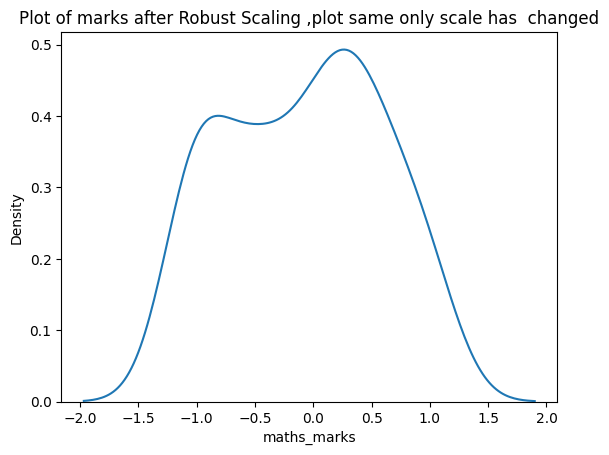

In [ ]:
sns.kdeplot(data=mark , x = mark['maths_marks'])
plt.title('Plot of marks after Robust Scaling ,plot same only scale has  changed' )

In [ ]:
mark['maths_marks'].describe()

count    100.000000
mean      -0.082081
std        0.670519
min       -1.167630
25%       -0.589595
50%        0.000000
75%        0.410405
max        1.098266
Name: maths_marks, dtype: float64